# DA Greedy Comparator: option 1 vs option 2 vs option 5

This notebook compares the **24-hour DA greedy strategy** (`option=1`) against the coarser parametrizations
`option=2` and `option=5`, with **`eta = 0.95`** and the **same remaining battery parameters** as in your original notebook.

It produces a 2x2 figure with:
1. **DA price curve**
2. **Cumulative PnL**
3. **DA power schedule**
4. **State of charge (SoC)**

**Assumption:** `cubic_spline.pkl` is available in the same working directory, just like in your original notebook.


In [129]:
import numpy as np
import cvxpy as cp
import pickle as pkl
import matplotlib.pyplot as plt

eta = 0.95

# Same battery settings as in the original notebook
I0 = 1.0
I_target = 1.0
Imax = 4.0
Bmax = 1.0

plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25


In [130]:
def optimize_battery_hourly_cvxpy(y, I0, I_target, Imax, Bmax, option=1, eta=0.95):
    """
    DA greedy optimization with different block parametrizations.

    Sign convention:
      B > 0  -> charge
      B < 0  -> discharge

    Objective:
      maximize - sum_t y_t B_t

    SoC dynamics:
      I_{t+1} = I_t + eta * c_t - (1/eta) * d_t
      with B_t = c_t - d_t
    """
    y = np.asarray(y, dtype=float)
    T = len(y)

    if T != 24 and option in [2, 5]:
        raise ValueError("option=2 and option=5 assume a 24-hour DA horizon.")

    I = cp.Variable(T + 1)
    constraints = [I[0] == I0]

    if option == 1:
        # Full hourly schedule
        c_ch = cp.Variable(T, nonneg=True)
        d_dis = cp.Variable(T, nonneg=True)
        z = cp.Variable(T, boolean=True)

        B = c_ch - d_dis

        for t in range(T):
            constraints.append(I[t + 1] == I[t] + eta * c_ch[t] - (1.0 / eta) * d_dis[t])

        constraints += [
            I >= 0,
            I <= Imax,
            c_ch <= Bmax,
            d_dis <= Bmax,
            c_ch <= Bmax * z,
            d_dis <= Bmax * (1 - z),
            I[T] == I_target,
        ]

    elif option == 2:
        # Two active blocks copied from the original notebook
        # block 0 -> hours 7..11
        # block 1 -> hours 16..19
        block_hours = {
            0: list(range(7, 12)),
            1: list(range(16, 20)),
        }

        n_blocks = 2
        c_blk = cp.Variable(n_blocks, nonneg=True)
        d_blk = cp.Variable(n_blocks, nonneg=True)
        z_blk = cp.Variable(n_blocks, boolean=True)

        c_list, d_list = [], []
        for t in range(T):
            assigned = False
            for b in range(n_blocks):
                if t in block_hours[b]:
                    c_list.append(c_blk[b])
                    d_list.append(d_blk[b])
                    assigned = True
                    break
            if not assigned:
                c_list.append(cp.Constant(0.0))
                d_list.append(cp.Constant(0.0))

        c_ch = cp.hstack(c_list)
        d_dis = cp.hstack(d_list)
        B = c_ch - d_dis

        for t in range(T):
            constraints.append(I[t + 1] == I[t] + eta * c_ch[t] - (1.0 / eta) * d_dis[t])

        constraints += [
            I >= 0,
            I <= Imax,
            c_blk <= Bmax,
            d_blk <= Bmax,
            c_blk <= Bmax * z_blk,
            d_blk <= Bmax * (1 - z_blk),
            I[T] == I_target,
        ]
    elif option == 3:
        # 5-block parametrization:
        # block 0 -> hour 1
        # block 1 -> hour 4
        # block 2 -> hours 7..11
        # block 3 -> hours 16..19
        # block 4 -> hour 23
        block_hours = {
            0: [1],
            1: [4],
            2: list(range(7, 12)),
            3: list(range(16, 20)),
            4: [23],
        }

        n_blocks = 5
        c_blk = cp.Variable(n_blocks, nonneg=True)
        d_blk = cp.Variable(n_blocks, nonneg=True)
        z_blk = cp.Variable(n_blocks, boolean=True)

        c_list, d_list = [], []

        for t in range(T):
            assigned = False
            for b in range(n_blocks):
                if t in block_hours[b]:
                    c_list.append(c_blk[b])
                    d_list.append(d_blk[b])
                    assigned = True
                    break
            if not assigned:
                c_list.append(cp.Constant(0.0))
                d_list.append(cp.Constant(0.0))

        c_ch = cp.hstack(c_list)
        d_dis = cp.hstack(d_list)
        B = c_ch - d_dis

        for i in range(T):
            constraints.append(
                I[i + 1] == I[i] + eta * c_ch[i] - (1.0 / eta) * d_dis[i]
            )

        constraints += [
            I >= 0,
            I <= Imax,
            c_blk <= Bmax,
            d_blk <= Bmax,
            c_blk <= Bmax * z_blk,
            d_blk <= Bmax * (1 - z_blk),
            I[T] == I_target,
        ]

    else:
        raise ValueError("option must be one of {1, 2, 5}.")

    objective = cp.Maximize(-y @ B)
    prob = cp.Problem(objective, constraints)
    prob.solve()

    if prob.status not in ["optimal", "optimal_inaccurate"]:
        raise RuntimeError(f"Optimization failed: {prob.status}")

    B_opt = np.asarray(B.value).flatten()
    I_opt = np.asarray(I.value).flatten()
    profit = float(prob.value)
    return B_opt, I_opt, profit


In [131]:
# Load the DA curve exactly as in the original notebook
with open("cubic_spline.pkl", "rb") as f:
    spline = pkl.load(f)

DA_curve = lambda t: spline["cs"](t)
hours = np.arange(24)
DA_lmp = np.asarray(DA_curve(hours), dtype=float)

print("DA_lmp shape:", DA_lmp.shape)
print("Price range:", float(DA_lmp.min()), "to", float(DA_lmp.max()))


DA_lmp shape: (24,)
Price range: 18.40523431034483 to 49.71490617816091


In [132]:
# Run the three comparators
results = {}
for opt in [1, 2, 3]:
    B_opt, I_opt, profit = optimize_battery_hourly_cvxpy(
        DA_lmp, I0=I0, I_target=I_target, Imax=Imax, Bmax=Bmax, option=opt, eta=eta
    )

    pnl_increment = -DA_lmp * B_opt
    pnl_cum = np.cumsum(pnl_increment)

    results[opt] = {
        "B": B_opt,
        "I": I_opt,
        "profit": profit,
        "pnl_increment": pnl_increment,
        "pnl_cum": pnl_cum,
    }

for opt in [1, 2, 3]:
    print(f"option={opt}: total profit = {results[opt]['profit']:.4f}")


option=1: total profit = 103.0852
option=2: total profit = 76.4056
option=3: total profit = 102.3595


In [133]:
def plot_da_greedy_comparator(DA_lmp, results, start_hour=2):
    labels = {
        1: "24-blocks",
        2: "2-blocks",
        3: "5-blocks",
    }

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

    hour_labels = [(h + start_hour) % 24 for h in hours]

    # ---- 1) Price curve ----
    ax = axes[0, 0]
    ax.plot(hours, DA_lmp, marker="x", linewidth=2, label=r"$P^{DA}$")
    ax.set_title(r"DA price curve", size=16)
    ax.set_ylabel("$/MWh", size=16)
    ax.set_xlabel("Hour", size=16)
    ax.set_xticks(hours)
    ax.set_xticklabels([f"{h:02d}:00" for h in hour_labels], rotation=90, fontsize=14)
    ax.legend(loc="lower right", fontsize=14)

    # ---- 2) Cumulative PnL ----
    ax = axes[0, 1]
    for opt in [1, 2, 3]:
        total_pnl = results[opt]["profit"]
        ax.plot(hours, results[opt]["pnl_cum"], linewidth=2, label=f"{labels[opt]} ({total_pnl:.3f}$)")
    ax.set_title(r"Running DA PnL $\Pi^{DA}$", size=16)
    ax.set_ylabel("Dollars ($)", size=16)
    ax.set_xlabel("Hour", size=16)
    ax.set_xticks(hours)
    ax.set_xticklabels([f"{h:02d}:00" for h in hour_labels], rotation=90, fontsize=14)
    ax.legend(loc="upper center", fontsize=13)

    # ---- 3) Power curve ----
    ax = axes[1, 0]
    for opt in [1, 2, 3]:
        ax.step(hours, results[opt]["B"], where="mid", linewidth=2, label=labels[opt])
        ax.plot(hours, results[opt]["B"], marker="x", linestyle="None")
    ax.axhline(0.0, color="black", linewidth=1, alpha=0.6)
    ax.set_title(r"DA power $B^{DA}$", size=16)
    ax.set_ylabel("MW", size=16)
    ax.set_xlabel("Hour", size=16)
    ax.set_xticks(hours)
    ax.set_xticklabels([f"{h:02d}:00" for h in hour_labels], rotation=90, fontsize=14)
    ax.legend(loc="lower center", bbox_to_anchor=(0.45, 0.02), fontsize=13)

    # ---- 4) SoC curve ----
    ax = axes[1, 1]
    soc_hours = np.arange(len(next(iter(results.values()))["I"]))
    soc_labels = [(h + start_hour) % 24 for h in soc_hours]

    for opt in [1, 2, 3]:
        ax.step(soc_hours, results[opt]["I"], where="post", linewidth=2, label=labels[opt])
    ax.set_title(r"Running DA inventory $I^{DA}$", size=16)
    ax.set_ylabel("MWh", size=16)
    ax.set_xlabel("Hour", size=16)
    ax.set_xticks(soc_hours)
    ax.set_xticklabels([f"{h:02d}:00" for h in soc_labels], rotation=90, fontsize=14)
    ax.legend(loc = "upper left",fontsize=13)

    for ax in axes.flat:
        ax.grid(True, alpha=0.25)

    plt.show()

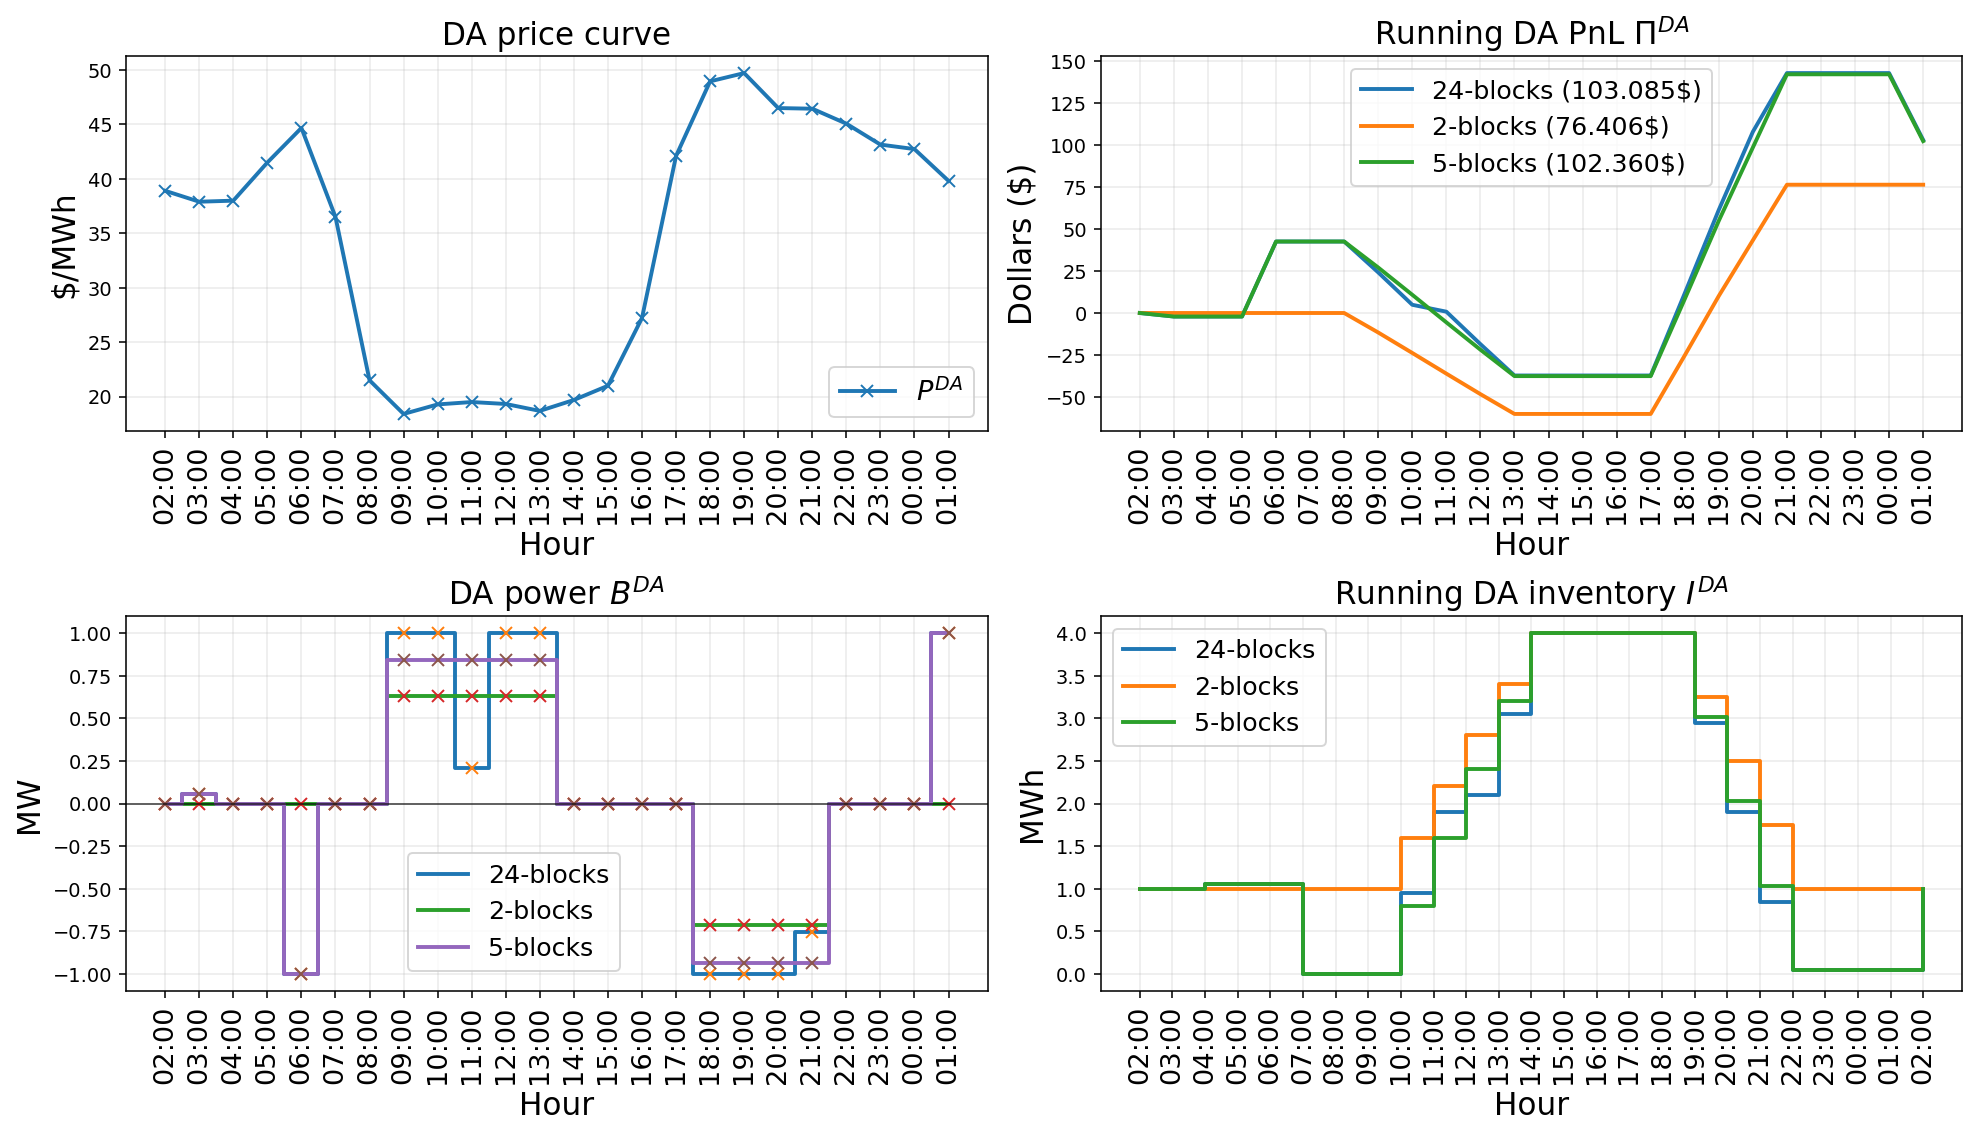

In [134]:
plot_da_greedy_comparator(DA_lmp, results, start_hour=2)